<a href="https://colab.research.google.com/github/xKevin441/SIS420-IA-Kevin-Tarqui/blob/main/Laboratorio_01_Regresi%C3%B3n_multivariable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 01
- **Nombre:** Tarqui Mita Kevin Rolando
- **Dataset:** Real-time Election Results: Portugal 2019
- **Caracteríscticas (n):** 29
- **Ejemplos (m):** 21643

## Descripción del Dataset
El Dataset contiene la evolución de los resultados electorales de las elecciones parlamentarias en Portugal en 2019, recogidos cada 5 minutos durante unas 4 h 25 min. Contiene información numérica sobre votos y mandatos de los partidos mientras se contabilizan resultados en tiempo real.

## Carga de los datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from google.colab import drive
drive.mount("/content/gdrive")
df = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/machine learning/datasets/ElectionData.csv")
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,TimeElapsed,time,territoryName,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,...,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Party,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
0,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PS,0,38.29,40.22,147993,94,106
1,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PPD/PSD,0,33.28,34.95,128624,81,77
2,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,B.E.,0,6.81,7.15,26307,16,19
3,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,CDS-PP,0,4.90,5.14,18923,12,5
4,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PCP-PEV,0,4.59,4.83,17757,11,12


### Selección de columnas
Se van a descartan las columnas no numéricas y las que no son de valor
- 'Votes' es el target, no puede ser una característica.
- 'Percentage' y 'validVotesPercentage' son derivadas directas de Votes.
- 'Hondt' y 'FinalMandates' son resultados post-elección.
- 'Mandates' es un resultado directo.
- 'time' y 'territoryName' son texto
- 'Party' es categórica, asi que cada partido, de esta columna, se convierte en una columna binaria, se asigna 1 si el voto fue para ese partido.

In [ ]:
EXCLUIR_COLS = ['Votes', 'Percentage', 'validVotesPercentage',
                'Hondt', 'FinalMandates', 'Mandates']
TEXT_COLS    = ['time', 'territoryName']
CATEGORICO_COLS     = ['Party']

df_copia = df.copy()

# Codificación One-Hot de la columna Party
party_dummies = pd.get_dummies(df_copia['Party'], prefix='party', drop_first=True)
df_copia = pd.concat([df_copia.drop(columns=CATEGORICO_COLS + TEXT_COLS), party_dummies], axis=1)
print(f'Columnas tras codificación: {df_copia.shape[1]}')

# Verificar y eliminar duplicados
n_dup = df_copia.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')
df_copia = df_copia.drop_duplicates().reset_index(drop=True)

# Confirmar ausencia de nulos
print(f'\nValores nulos por columna:')
print(df_copia.isnull().sum()[df_copia.isnull().sum() > 0])

print(f'\nShape final del dataset limpio: {df_copia.shape}')

Columnas tras codificación: 45
Filas duplicadas: 0

Valores nulos por columna:
Series([], dtype: int64)

Shape final del dataset limpio: (21643, 45)


## Variable Objetivo
Se toma como variable objetivo la variable **Votes**.

In [ ]:
# Separar X e y
# Se usan TODAS las columnas disponibles (sin leakage)
objetivo_col = 'Votes'
feature_cols = [c for c in df_copia.columns if c != objetivo_col]

X_raw = df_copia[feature_cols].values.astype(np.float64)
y = df_copia[objetivo_col].values.astype(np.float64)

print(f'Features utilizadas ({len(feature_cols)}):')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')
print(f'\nShape X: {X_raw.shape}')
print(f'Shape y: {y.shape}')

Features utilizadas (44):
   1. TimeElapsed
   2. totalMandates
   3. availableMandates
   4. numParishes
   5. numParishesApproved
   6. blankVotes
   7. blankVotesPercentage
   8. nullVotes
   9. nullVotesPercentage
  10. votersPercentage
  11. subscribedVoters
  12. totalVoters
  13. pre.blankVotes
  14. pre.blankVotesPercentage
  15. pre.nullVotes
  16. pre.nullVotesPercentage
  17. pre.votersPercentage
  18. pre.subscribedVoters
  19. pre.totalVoters
  20. Mandates
  21. Percentage
  22. validVotesPercentage
  23. Hondt
  24. FinalMandates
  25. party_B.E.
  26. party_CDS-PP
  27. party_CH
  28. party_IL
  29. party_JPP
  30. party_L
  31. party_MAS
  32. party_MPT
  33. party_NC
  34. party_PAN
  35. party_PCP-PEV
  36. party_PCTP/MRPP
  37. party_PDR
  38. party_PNR
  39. party_PPD/PSD
  40. party_PPM
  41. party_PS
  42. party_PTP
  43. party_PURP
  44. party_R.I.R.

Shape X: (21643, 44)
Shape y: (21643,)


In [ ]:
# División Train / Test (80/20)
np.random.seed(42)
n = X_raw.shape[0]
idx = np.random.permutation(n)
split = int(0.8 * n)

train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
y_train,     y_test     = y[train_idx],     y[test_idx]

print(f'Train: {X_train_raw.shape[0]} muestras')
print(f'Test : {X_test_raw.shape[0]} muestras')

Train: 17314 muestras
Test : 4329 muestras


## Normalización

In [ ]:
def  normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X_train_norm, mu, sigma = normalizarCaracteristicas(X_train_raw)
X_test_norm = (X_test_raw - mu) / sigma

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

Media calculada: [1.32754707e+02 1.17358785e+01 1.14901814e+01 3.12651554e+02
 2.64488102e+02 9.00236629e+03 2.61857976e+00 6.23800410e+03
 1.96013111e+00 5.19844265e+01 6.37036472e+05 3.44226802e+05
 7.71764826e+03 2.06903835e+00 6.00145333e+03 1.77554349e+00
 5.45616674e+01 6.47437098e+05 3.64945163e+05 5.58854107e-01
 4.90910419e+00 5.14467194e+00 1.12625621e+00 1.12521659e+00
 5.14034885e-02 5.14034885e-02 5.20388125e-02 5.25008664e-02
 2.29294213e-02 5.23275962e-02 1.96372877e-02 4.68407069e-02
 4.54545455e-02 5.10569481e-02 5.38870278e-02 5.11147049e-02
 5.16345154e-02 5.15767587e-02 5.27318933e-02 5.11724616e-02
 5.03638674e-02 4.60898695e-02 4.56278156e-02 4.70717339e-02]
Desviación estandar calculada: [7.74133078e+01 3.19381054e+01 3.15223213e+01 6.64748302e+02
 5.92197827e+02 2.18712143e+04 7.94620928e-01 1.49986791e+04
 3.74934179e-01 4.84524287e+00 1.55324584e+06 8.44011383e+05
 1.88279089e+04 5.16919936e-01 1.44926876e+04 3.88202819e-01
 4.95181392e+00 1.57237714e+06 8.922

In [ ]:
# Agregar columna de bias (intercepto) a X
def agregar_unos(X):
    """Agrega columna de unos al inicio de X."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = agregar_unos(X_train_norm)
X_test_b  = agregar_unos(X_test_norm)

n_features = X_train_b.shape[1]   # incluye bias
print(f'Shape X_train con bias: {X_train_b.shape}')
print(f'Número de parámetros θ: {n_features}')

Shape X_train con bias: (17314, 45)
Número de parámetros θ: 45


## Función de costo


In [ ]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

## Descenso por el gradiente

In [ ]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
    m = len(y)
    theta = theta.copy()

    J_history = []

    for i in range(numero_iteraciones):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

Costo inicial : 2866712124.709649
Costo final   : 78092416.675541
Reducción     : 97.28%


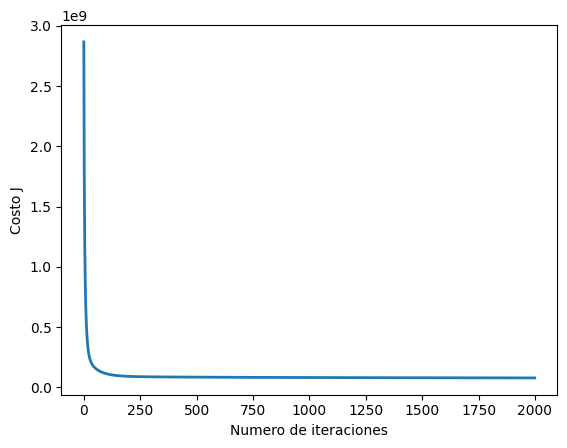

In [ ]:
# Entrenamiento final con la mejor tasa
# Se elige α=0.05 por su convergencia estable y rápida
ALPHA = 0.05
N_ITER = 2000

theta_init  = np.zeros(n_features)
theta_final, J_history = calcularDescensoGradiente(
    X_train_b, y_train, theta_init, ALPHA, N_ITER
)

# Grafica la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')

print(f'Costo inicial : {history[0]:.6f}')
print(f'Costo final   : {history[-1]:.6f}')
print(f'Reducción     : {(1 - history[-1]/history[0])*100:.2f}%')

## Predicción y cálculo de la presición

In [ ]:
def prediccion(X, theta):
    return np.dot(X, theta)

In [ ]:
y_pred_train = prediccion(X_train_b, theta_final)
y_pred_test  = prediccion(X_test_b,  theta_final)

print('Primeras 5 predicciones vs valores reales (test):')
for real, pred in zip(y_test[:5], y_pred_test[:5]):
    print(f'  Real: {real:10,.0f}  |  Predicho: {pred:10,.0f}  |  Error: {abs(real-pred):,.0f}')

Primeras 5 predicciones vs valores reales (test):
  Real:     51,030  |  Predicho:     31,110  |  Error: 19,920
  Real:      1,432  |  Predicho:        941  |  Error: 491
  Real:         26  |  Predicho:     -2,604  |  Error: 2,630
  Real:        543  |  Predicho:        817  |  Error: 274
  Real:        586  |  Predicho:      2,008  |  Error: 1,422


In [ ]:
# Métricas de evaluación
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ssr = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ssr / sst)

mse_train = mse(y_train, y_pred_train)
rmse_train = rmse(y_train, y_pred_train)
mae_train = mae(y_train, y_pred_train)
r2_train = r2(y_train, y_pred_train)

mse_test = mse(y_test, y_pred_test)
rmse_test = rmse(y_test, y_pred_test)
mae_test = mae(y_test, y_pred_test)
r2_test = r2(y_test, y_pred_test)

print('Métricas de evaluación:')
print(f'  MSE (Train): {mse_train:.2f} | MSE (Test): {mse_test:.2f}')
print(f'  RMSE (Train): {rmse_train:.2f} | RMSE (Test): {rmse_test:.2f}')
print(f'  MAE (Train): {mae_train:.2f} | MAE (Test): {mae_test:.2f}')
print(f'  R^2 (Train): {r2_train * 100:.2f}% | R^2 (Test): {r2_test * 100:.2f}%')

Métricas de evaluación:
  MSE (Train): 156184833.35 | MSE (Test): 140469498.27
  RMSE (Train): 12497.39 | RMSE (Test): 11851.98
  MAE (Train): 4813.56 | MAE (Test): 4783.45
  R^2 (Train): 98.20% | R^2 (Test): 98.38%


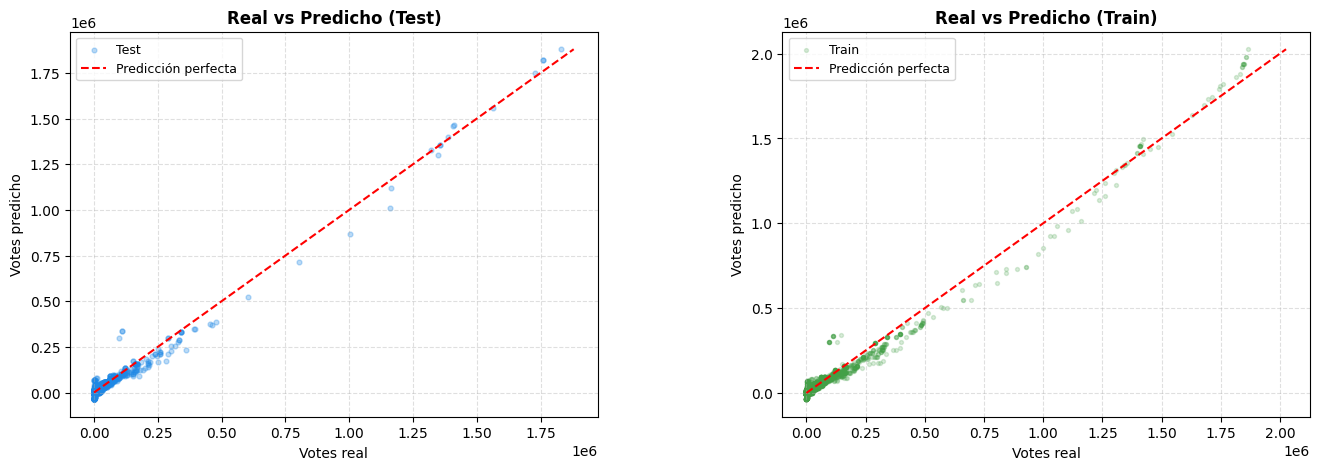

In [ ]:
import matplotlib.gridspec as gridspec
# Gráficas de evaluación
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# (a) Real vs Predicho — Test
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_test, alpha=0.3, s=12, color='#1E88E5', label='Test')
lim = max(y_test.max(), y_pred_test.max())
ax1.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
ax1.set_title('Real vs Predicho (Test)', fontweight='bold')
ax1.set_xlabel('Votes real')
ax1.set_ylabel('Votes predicho')
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# (b) Real vs Predicho — Train
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_train, y_pred_train, alpha=0.2, s=8, color='#43A047', label='Train')
lim2 = max(y_train.max(), y_pred_train.max())
ax2.plot([0, lim2], [0, lim2], 'r--', linewidth=1.5, label='Predicción perfecta')
ax2.set_title('Real vs Predicho (Train)', fontweight='bold')
ax2.set_xlabel('Votes real')
ax2.set_ylabel('Votes predicho')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)